In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def compute_mean_rate_1D(
    flux_file: str,
    dt_ps: float = 5.0,
    window_time: float = 5e-10
):

    # ------------------------------------------------------------
    # Read data
    # ------------------------------------------------------------
    data = []
    with open(flux_file, "r") as f:
        for line in f:
            if not line.strip().startswith("Iteration"):
                continue
            try:
                parts = [p.strip() for p in line.split(",")]
                it  = int(parts[0].split()[1])
                wt  = float(parts[2].split(":")[1])
                data.append([it, wt])
            except Exception:
                continue

    if not data:
        raise ValueError("No valid lines found in flux file")

    data = np.asarray(data, dtype=float)
    its     = data[:, 0].astype(int)
    weights = data[:, 1]
    # ------------------------------------------------------------
    # Normalize iteration indices
    # ------------------------------------------------------------
    min_iter = its.min()
    iter_idx = its - min_iter
    n_iters  = iter_idx.max() + 1

    # Use weights from the flux files.
    effective_weights = weights.copy()
    # ------------------------------------------------------------
    # Aggregate flux per iteration
    # ------------------------------------------------------------
    flux = np.bincount(
        iter_idx,
        weights=effective_weights,
        minlength=n_iters
    )

    # ------------------------------------------------------------
    # Time scaling + running mean
    # ------------------------------------------------------------
    tau = dt_ps * 1e-12
    window_frames = max(1, int(window_time / tau))

    rates = np.zeros(len(flux))
    for i in range(len(flux)):
        start = max(0, i - window_frames + 1)
        rates[i] = np.mean(flux[start : i + 1]) / tau

    time_ns = (np.arange(n_iters) + 1) * tau * 1e9

    return time_ns, rates


def bayesian_bootstrap_mean_ci(values, n_boot=20000, ci=0.95, random_state=0):
    """
    Bayesian bootstrap for mean and credible interval.

    values: array-like, shape (n_samples,)
    """
    rng = np.random.default_rng(random_state)
    n = len(values)

    # Dirichlet weights
    weights = rng.dirichlet(np.ones(n), size=n_boot)

    # Posterior samples of the mean
    means = weights @ values

    mean_est = means.mean()
    alpha = (1 - ci) / 2
    lo, hi = np.quantile(means, [alpha, 1 - alpha])

    return mean_est, lo, hi
def mean_ci_from_replicas(t_ref, lts, lrs, npts=2500):
    """
    Interpolate replicas onto a common time grid and compute
    Bayesian bootstrap mean and CI.
    """
    t_common = t_ref[:npts]

    interp_vals = [
        np.interp(t_common, lt, lr) for lt, lr in zip(lts[1:], lrs[1:])
    ]

    mean = np.zeros_like(t_common)
    lo   = np.zeros_like(t_common)
    hi   = np.zeros_like(t_common)

    for i in range(len(t_common)):
        vals = np.array([lrs[0][i]] + [v[i] for v in interp_vals])
        m, l, h = bayesian_bootstrap_mean_ci(vals)
        mean[i], lo[i], hi[i] = m, l, h

    return t_common, mean, lo, hi

def mean_ci_upto_1000(time_arrays, rate_arrays, npts=1000):
    """
    Compute Bayesian bootstrap mean and CI up to npts,
    using only existing values at each index.

    time_arrays : list of 1D arrays
    rate_arrays : list of 1D arrays
    """
    t_common = time_arrays[0][:npts]

    mean = np.zeros(npts)
    lo   = np.zeros(npts)
    hi   = np.zeros(npts)

    for i in range(npts):
        vals = []

        for t, r in zip(time_arrays, rate_arrays):
            if i < len(r):
                vals.append(r[i])

        vals = np.asarray(vals)

        m, l, h = bayesian_bootstrap_mean_ci(vals)
        mean[i], lo[i], hi[i] = m, l, h

    return t_common, mean, lo, hi

In [3]:
wt_path11 = "./data/assets/1OPJ/WT/flux_files/wt_ac_flux_1.txt"
wt_path12 = "./data/assets/1OPJ/WT/flux_files/wt_ac_flux_2.txt"
wt_path13 = "./data/assets/1OPJ/WT/flux_files/wt_ac_flux_3.txt"

wt_path21 = "./data/assets/1OPJ/WT/flux_files/wt_ploop_flux_1.txt"
wt_path22 = "./data/assets/1OPJ/WT/flux_files/wt_ploop_flux_2.txt"
wt_path23 = "./data/assets/1OPJ/WT/flux_files/wt_ploop_flux_3.txt"

In [4]:
time_wt11, rate_wt11  = compute_mean_rate_1D(wt_path11, dt_ps = 40.0,
                                            window_time=2.5e-9)
time_wt12, rate_wt12  = compute_mean_rate_1D(wt_path12, dt_ps = 40.0,
                                            window_time=2.5e-9)

time_wt13, rate_wt13  = compute_mean_rate_1D(wt_path13, dt_ps = 40.0,
                                             window_time=2.5e-9)

time_wt21, rate_wt21  = compute_mean_rate_1D(wt_path21, dt_ps = 40.0,
                                            window_time=2.0e-9)

time_wt22, rate_wt22  = compute_mean_rate_1D(wt_path22, dt_ps = 40.0,
                                             window_time=2.0e-9)

time_wt23, rate_wt23  = compute_mean_rate_1D(wt_path23, dt_ps = 40.0,
                                             window_time=2.0e-9)

In [5]:
t_common_wt2 = time_wt21[:1000]
hr2i = np.interp(t_common_wt2, time_wt22, rate_wt22)
hr3i = np.interp(t_common_wt2, time_wt23, rate_wt23)
mean_rate_wt2 = np.zeros_like(t_common_wt2)
lo_rate_wt2  = np.zeros_like(t_common_wt2)
hi_rate_wt2   = np.zeros_like(t_common_wt2)

for i in range(len(t_common_wt2)):
    vals = np.array([rate_wt21[i], rate_wt22[i], rate_wt23[i]])
    m, lo, hi = bayesian_bootstrap_mean_ci(vals)
    mean_rate_wt2[i] = m
    lo_rate_wt2[i] = lo
    hi_rate_wt2[i] = hi

t_common_wt1 = time_wt11[:1000]
hr2i = np.interp(t_common_wt1, time_wt12, rate_wt12)
hr3i = np.interp(t_common_wt1, time_wt13, rate_wt13)
mean_rate_wt1 = np.zeros_like(t_common_wt1)
lo_rate_wt1  = np.zeros_like(t_common_wt1)
hi_rate_wt1   = np.zeros_like(t_common_wt1)

for i in range(len(t_common_wt1)):
    vals = np.array([rate_wt11[i], rate_wt12[i], rate_wt13[i]])
    m, lo, hi = bayesian_bootstrap_mean_ci(vals)
    mean_rate_wt1[i] = m
    lo_rate_wt1[i] = lo
    hi_rate_wt1[i] = hi

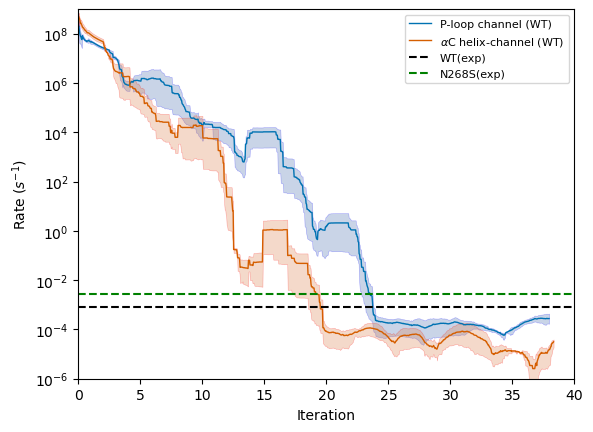

In [6]:
color_low = "#4C72B0"
color_high = "#DD8452"
colorlow="#0072B2"
colorhigh="#D55E00"

# color_MUT = "cornflowerblue"
# colorMUT = "midnightblue"
# color_WT = "lightcoral"
# colorWT = "firebrick"

plt.plot(t_common_wt1, mean_rate_wt1, color=colorlow, lw=1,
         label="P-loop channel (WT)")

plt.fill_between(
    t_common_wt1,
    lo_rate_wt1,
    hi_rate_wt1,
    color=color_low,
    alpha=0.3,
    lw = 0.4, edgecolor = "b", ls = "-"
)

plt.plot(t_common_wt2, mean_rate_wt2, color=colorhigh, lw=1,
         label=r"$\alpha$C helix-channel (WT)")

plt.fill_between(
    t_common_wt2,
    lo_rate_wt2,
    hi_rate_wt2,
    color=color_high,
    alpha=0.3,
    lw = 0.4, edgecolor = "r", ls = "-"
)
plt.xlabel('Iteration')
plt.ylabel(r'Rate ($s^{-1}$)')

# plt.grid(True)
plt.axhline( y = 8.3e-4, ls = "--", c = "k", label = "WT(exp)")
plt.axhline( y = 2.7e-3, ls = "--", c = "g",label = "N268S(exp)")
plt.legend(loc = "upper right", fontsize = 8)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(1e-6, 1e9)
plt.show()

In [7]:
mut_path11 = "./data/assets/1OPJ/N368S/flux_files/n368s_ac_flux_1.txt"
mut_path12 = "./data/assets/1OPJ/N368S/flux_files/n368s_ac_flux_2.txt"
mut_path13 = "./data/assets/1OPJ/N368S/flux_files/n368s_ac_flux_3.txt"

mut_path21 = "./data/assets/1OPJ/N368S/flux_files/n368s_ploop_flux_1.txt"
mut_path22 = "./data/assets/1OPJ/N368S/flux_files/n368s_ploop_flux_2.txt"
mut_path23 = "./data/assets/1OPJ/N368S/flux_files/n368s_ploop_flux_3.txt"

In [8]:
time_mut11, rate_mut11  = compute_mean_rate_1D(mut_path11, dt_ps = 40.0, window_time=2.0e-9)

time_mut12, rate_mut12  = compute_mean_rate_1D(mut_path12, dt_ps = 40.0, window_time=2.0e-9)

time_mut13, rate_mut13  = compute_mean_rate_1D(mut_path13, dt_ps = 40.0, window_time=2.0e-9)

time_mut21, rate_mut21  = compute_mean_rate_1D(mut_path21, dt_ps = 40.0, window_time=3.0e-9)

time_mut22, rate_mut22  = compute_mean_rate_1D(mut_path22, dt_ps = 40.0, window_time=3.0e-9)

time_mut23, rate_mut23  = compute_mean_rate_1D(mut_path23, dt_ps = 40.0, window_time=3.0e-9)

In [9]:
# Truncate reference time to 1000
t_common_mut1 = time_mut11[:1000]

time_arrays = [time_mut11, time_mut12, time_mut13]

rate_arrays = [rate_mut11, rate_mut12, rate_mut13]

mean_rate_mut1 = np.zeros_like(t_common_mut1)
lo_rate_mut1   = np.zeros_like(t_common_mut1)
hi_rate_mut1   = np.zeros_like(t_common_mut1)

for i in range(len(t_common_mut1)):
    vals = []

    if i < len(rate_mut11):
        vals.append(rate_mut11[i])
    if i < len(rate_mut12):
        vals.append(rate_mut12[i])
    if i < len(rate_mut13):
        vals.append(rate_mut13[i])

    vals = np.asarray(vals)

    m, lo, hi = bayesian_bootstrap_mean_ci(vals)

    mean_rate_mut1[i] = m
    lo_rate_mut1[i]   = lo
    hi_rate_mut1[i]   = hi

In [10]:
# Truncate reference time to 1000
t_common_mut2 = time_mut21[:1000]

time_arrays = [time_mut21, time_mut22, time_mut23]

rate_arrays = [rate_mut21, rate_mut22, rate_mut23]

mean_rate_mut2 = np.zeros_like(t_common_mut2)
lo_rate_mut2   = np.zeros_like(t_common_mut2)
hi_rate_mut2   = np.zeros_like(t_common_mut2)

for i in range(len(t_common_mut2)):
    vals = []

    if i < len(rate_mut21):
        vals.append(rate_mut21[i])
    if i < len(rate_mut22):
        vals.append(rate_mut22[i])
    if i < len(rate_mut23):
        vals.append(rate_mut23[i])

    vals = np.asarray(vals)

    m, lo, hi = bayesian_bootstrap_mean_ci(vals)

    mean_rate_mut2[i] = m
    lo_rate_mut2[i]   = lo
    hi_rate_mut2[i]   = hi

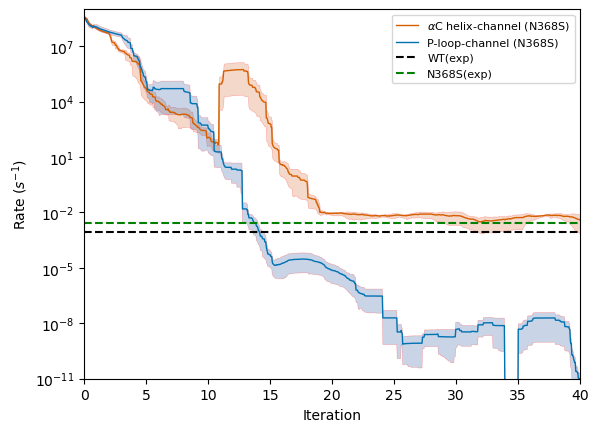

In [11]:
color_low = "#4C72B0"
color_high = "#DD8452"
colorlow="#0072B2"
colorhigh="#D55E00"

plt.plot(t_common_mut1, mean_rate_mut1, color=colorhigh, lw=1,
         label=r"$\alpha$C helix-channel (N368S)")

plt.fill_between(
    t_common_mut1,
    lo_rate_mut1,
    hi_rate_mut1,
    color=color_high,
    alpha=0.3,
    lw = 0.4, edgecolor = "r", ls = "-"
)

plt.plot(t_common_mut2, mean_rate_mut2, color=colorlow, lw=1,
         label=r"P-loop-channel (N368S)")

plt.fill_between(
    t_common_mut2,
    lo_rate_mut2,
    hi_rate_mut2,
    color=color_low,
    alpha=0.3,
    lw = 0.4, edgecolor = "r", ls = "-"
)

plt.xlabel('Iteration')
plt.ylabel(r'Rate ($s^{-1}$)')
# plt.title('Weighted Ensemble Transition Rate Convergence')

# plt.grid(True)
plt.axhline( y = 8.3e-4, ls = "--", c = "k", label = "WT(exp)")
plt.axhline( y = 2.7e-3, ls = "--", c = "g",label = "N368S(exp)")
plt.legend(loc = "upper right", fontsize = 8)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(1e-11, 1e9)
plt.show()